In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/IndianWeatherRepository.csv")

print(df.shape)
df.head()

(118298, 42)


,country,location_name,region,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,India,Ashoknagar,Madhya Pradesh,24.57,77.72,Asia/Kolkata,1693286100,2023-08-29 10:45,27.5,81.5,...,12.6,18.5,1,2,05:59 AM,06:41 PM,05:42 PM,03:38 AM,Waxing Gibbous,93
1,India,Raisen,Madhya Pradesh,23.33,77.80,Asia/Kolkata,1693286100,2023-08-29 10:45,27.5,81.5,...,10.7,14.2,1,1,06:00 AM,06:40 PM,05:39 PM,03:41 AM,Waxing Gibbous,93
2,India,Chhindwara,Madhya Pradesh,22.07,78.93,Asia/Kolkata,1693286100,2023-08-29 10:45,26.3,79.3,...,16.8,20.7,2,2,05:56 AM,06:34 PM,05:32 PM,03:39 AM,Waxing Gibbous,93
3,India,Betul,Madhya Pradesh,21.86,77.93,Asia/Kolkata,1693286100,2023-08-29 10:45,25.6,78.1,...,4.9,6.6,1,1,06:00 AM,06:38 PM,05:36 PM,03:43 AM,Waxing Gibbous,93
4,India,Hoshangabad,Madhya Pradesh,22.75,77.72,Asia/Kolkata,1693286100,2023-08-29 10:45,27.2,81.0,...,11.4,14.8,1,1,06:01 AM,06:39 PM,05:38 PM,03:42 AM,Waxing Gibbous,93


In [2]:
drop_cols = [
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'visibility_miles',
    'gust_mph',
    'country',
    'last_updated'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [3]:
df['last_updated_epoch'] = pd.to_datetime(
    df['last_updated_epoch'],
    unit='s'
)

df['year'] = df['last_updated_epoch'].dt.year
df['month'] = df['last_updated_epoch'].dt.month
df['day'] = df['last_updated_epoch'].dt.day
df['hour'] = df['last_updated_epoch'].dt.hour
df['dayofweek'] = df['last_updated_epoch'].dt.dayofweek

In [4]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'location_name',
    'region',
    'timezone',
    'condition_text',
    'wind_direction',
    'moon_phase'
]

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

In [5]:
TARGET = "cloud"

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

X_train = X_train.copy()
X_test = X_test.copy()

X_train['last_updated_epoch'] = X_train['last_updated_epoch'].astype('int64') // 10**9
X_test['last_updated_epoch'] = X_test['last_updated_epoch'].astype('int64') // 10**9

time_cols = ['sunrise', 'sunset', 'moonrise', 'moonset']

def parse_time_to_minutes(series):
    parsed = pd.to_datetime(series, format='%I:%M %p', errors='coerce')
    return parsed.dt.hour * 60 + parsed.dt.minute

for col in time_cols:
    X_train[col] = parse_time_to_minutes(X_train[col])
    X_test[col] = parse_time_to_minutes(X_test[col])

model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(
    mean_squared_error(y_test, pred)
)

r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 5.0193562507629395
RMSE: 7.456836088413295
R²  : 0.9368841648101807


In [11]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
7             condition_text    0.396704
12                 precip_mm    0.273602
13                  humidity    0.045352
33                      year    0.040508
24          air_quality_PM10    0.039855
16             visibility_km    0.035969
25  air_quality_us-epa-index    0.013880
15     feels_like_fahrenheit    0.013055
11               pressure_mb    0.012682
3                  longitude    0.011343
14        feels_like_celsius    0.010160
36                      hour    0.009964
34                     month    0.008667
17                  uv_index    0.008187
8                   wind_kph    0.005712
23         air_quality_PM2.5    0.005656
32         moon_illumination    0.005556
2                   latitude    0.004811
30                   moonset    0.004746
35                       day    0.004521


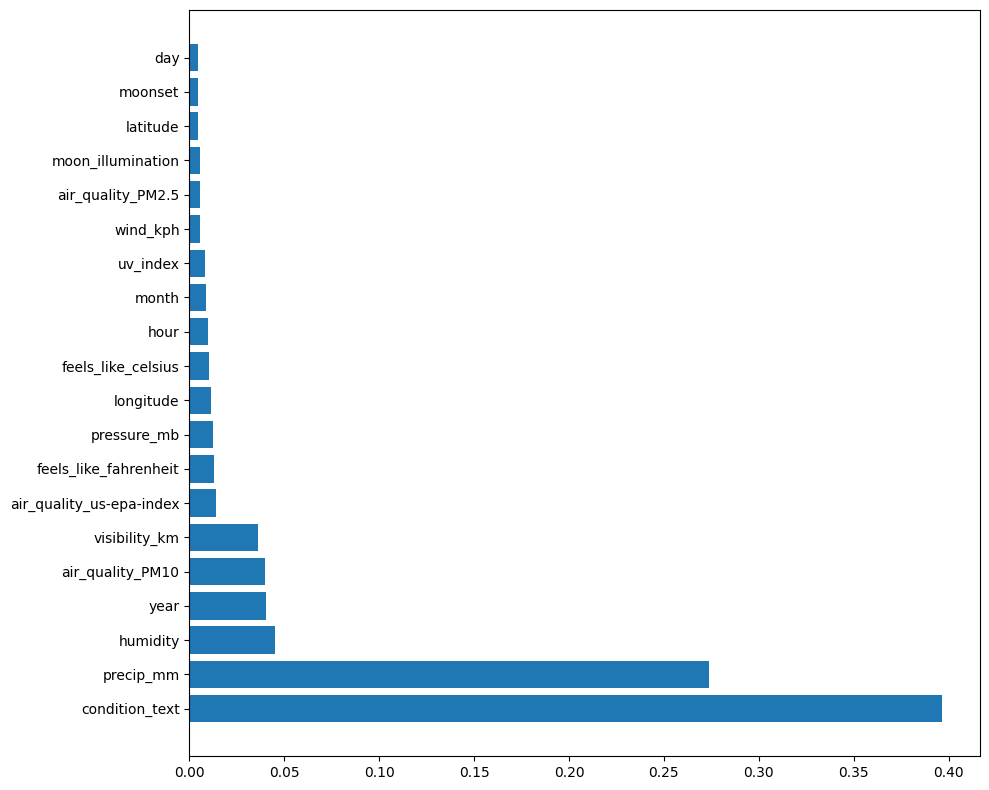

In [18]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.tight_layout()

plt.show()

In [21]:
df = df.sort_values("last_updated_epoch")

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df.drop(columns=["cloud"])
y_train = train_df["cloud"]

X_test = test_df.drop(columns=["cloud"])
y_test = test_df["cloud"]

In [17]:
print(y_test)

94723      5
94724      8
94725      6
94740     71
94726      6
          ..
118083    25
118082     4
118081     4
118088     0
118297     7
Name: cloud, Length: 23660, dtype: int64


In [22]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:last_updated_epoch: datetime64[ns], sunrise: object, sunset: object, moonrise: object, moonset: object

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

acc = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

NameError: name 'y_pred' is not defined